# Fase 1 - Modelo predictivo para Kaggle
## Competición: Predicting Heart Disease
### Playground Series - Season 6 Episode 2

En este notebook desarrollamos un modelo predictivo para la competición seleccionada en Kaggle.  
El objetivo es entrenar un modelo de clasificación que permita predecir la variable objetivo `Heart Disease` a partir de las variables disponibles en el conjunto de datos.

Además, se genera un archivo `submission.csv` con el formato requerido por la competición y se guarda el modelo entrenado para poder reutilizarlo en las siguientes fases del proyecto.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import joblib

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
sample_submission = pd.read_csv("/content/sample_submission.csv")

In [3]:
target = "Heart Disease"

X = train.drop(columns=[target, "id"])
y = train[target]

X_test = test.drop(columns=["id"])

In [4]:
print("Shape de train:", train.shape)
print("Shape de test:", test.shape)
print("Shape de sample_submission:", sample_submission.shape)

Shape de train: (630000, 15)
Shape de test: (270000, 14)
Shape de sample_submission: (270000, 2)


In [5]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

## Estadísticas descriptivas

En esta sección observamos un resumen estadístico de las variables numéricas del conjunto de entrenamiento.  
Esto nos permite identificar rangos, medias y posibles comportamientos generales de los datos.

In [9]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


## Distribución de la variable objetivo

Ahora revisamos cómo se distribuyen las clases de la variable `Heart Disease`.  
Esto es importante porque nos permite entender si el problema está balanceado o desbalanceado.

In [10]:
print(train["Heart Disease"].value_counts())
print()
print(train["Heart Disease"].value_counts(normalize=True))

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64


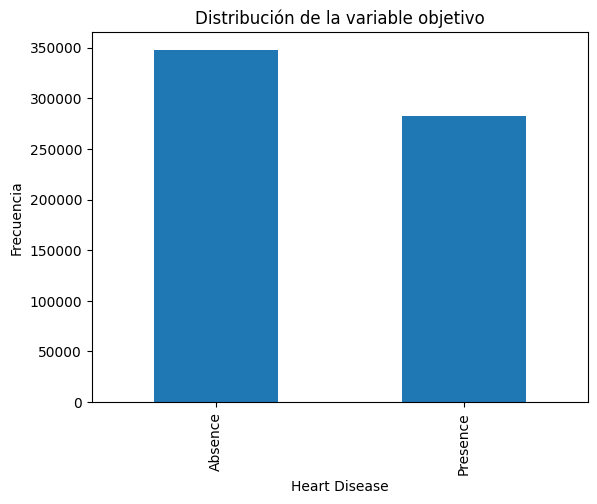

In [11]:
train["Heart Disease"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Heart Disease")
plt.ylabel("Frecuencia")
plt.show()

## Preparación de variables

Separamos la variable objetivo de las variables predictoras.  
También eliminamos la columna `id`, ya que solo funciona como identificador y no aporta valor predictivo al modelo.

In [12]:
target = "Heart Disease"

X = train.drop(columns=[target, "id"])
y = train[target]

X_test = test.drop(columns=["id"])

## Definición de variables numéricas y categóricas

Aunque varias columnas aparecen como enteros, algunas representan categorías codificadas y no cantidades continuas.  
Por eso definimos manualmente cuáles variables trataremos como categóricas y cuáles como numéricas.

In [13]:
cat_cols = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium"
]

num_cols = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

print("Columnas categóricas:", cat_cols)
print("Columnas numéricas:", num_cols)

Columnas categóricas: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Columnas numéricas: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']


## Preprocesamiento de los datos

Construimos dos flujos de transformación:

- Para las variables numéricas: imputación por mediana y escalado.
- Para las variables categóricas: imputación por la categoría más frecuente y codificación one-hot.

Esto permite que el modelo procese correctamente ambos tipos de variables.

In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

## División en entrenamiento y validación

Dividimos el conjunto de datos en dos partes:

- una para entrenar el modelo,
- otra para validar su desempeño.

La división es estratificada para conservar la proporción de clases.

In [15]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Shape X_train:", X_train.shape)
print("Shape X_valid:", X_valid.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_valid:", y_valid.shape)

Shape X_train: (504000, 13)
Shape X_valid: (126000, 13)
Shape y_train: (504000,)
Shape y_valid: (126000,)


## Construcción del modelo

Usamos una regresión logística dentro de un pipeline.  
Esto nos permite integrar el preprocesamiento y el modelo en una sola estructura reproducible y fácil de reutilizar más adelante.

In [17]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

## Entrenamiento del modelo

En esta etapa ajustamos el modelo con los datos de entrenamiento.

In [18]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BP', 'Cholesterol',
                                                   'Max HR', 'ST depression']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Chest pain type',
                                                   'FBS over 120',
                                                   'EKG results',
                                                   'Exercise angina',
                                                   'Slope of ST',
                                                   'Number of vessels fluro',
                                                   'Thallium'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

## Verificación de clases aprendidas por el modelo

Revisamos el orden de las clases internas del clasificador para identificar correctamente la probabilidad asociada a `Presence`.

In [19]:
classes = model.named_steps["classifier"].classes_
print("Clases del modelo:", classes)

presence_index = list(classes).index("Presence")
print("Índice de la clase 'Presence':", presence_index)

Clases del modelo: ['Absence' 'Presence']
Índice de la clase 'Presence': 1


## Evaluación del modelo

Calculamos métricas sobre el conjunto de validación para medir el desempeño inicial del modelo.  
Usamos:

- Accuracy
- ROC AUC
- Reporte de clasificación
- Matriz de confusión

In [20]:
y_pred = model.predict(X_valid)
y_proba = model.predict_proba(X_valid)[:, presence_index]

y_valid_binary = (y_valid == "Presence").astype(int)

print("Accuracy:", accuracy_score(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid_binary, y_proba))
print("\nReporte de clasificación:")
print(classification_report(y_valid, y_pred))

Accuracy: 0.8870555555555556
ROC AUC: 0.9537010543765575

Reporte de clasificación:
              precision    recall  f1-score   support

     Absence       0.89      0.91      0.90     69509
    Presence       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [21]:
cm = confusion_matrix(y_valid, y_pred)
print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[63115  6394]
 [ 7837 48654]]


## Predicciones sobre el conjunto de prueba

Una vez validado el modelo, generamos las probabilidades para el conjunto `test.csv`.  
Estas probabilidades se utilizarán para construir el archivo final de envío a Kaggle.

In [22]:
test_proba = model.predict_proba(X_test)[:, presence_index]

## Construcción del archivo de submission

Creamos el archivo `submission.csv` con el formato requerido por la competición:

- `id`
- `Heart Disease`

La segunda columna contiene la probabilidad estimada de la clase positiva (`Presence`).

In [23]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": test_proba
})

submission.head()

,id,Heart Disease
0,630000,0.893169
1,630001,0.004940
2,630002,0.989173
3,630003,0.005611
4,630004,0.265214


In [24]:
sample_submission.head()

,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [25]:
submission.to_csv("/content/submission.csv", index=False)
print("Archivo submission.csv generado correctamente en /content/submission.csv")

Archivo submission.csv generado correctamente en /content/submission.csv


## Guardado del modelo entrenado

Guardamos el modelo en disco para reutilizarlo en las siguientes fases del proyecto, especialmente en la creación de scripts y en el despliegue dentro de Docker.

In [26]:
joblib.dump(model, "/content/model.joblib")
print("Modelo guardado correctamente en /content/model.joblib")

Modelo guardado correctamente en /content/model.joblib


## Conclusiones

En esta fase construimos un modelo predictivo funcional para la competición **Predicting Heart Disease**.

El proceso incluyó la carga de datos, la exploración inicial, la separación de variables, la definición de atributos numéricos y categóricos, el preprocesamiento mediante un pipeline, el entrenamiento de una regresión logística y su evaluación con un conjunto de validación.

Finalmente, generamos el archivo `submission.csv` con el formato requerido por Kaggle y almacenamos el modelo entrenado en disco como `model.joblib`, lo cual permitirá reutilizarlo en las siguientes fases del proyecto.